In [ ]:
import pandas as pd

column_names = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship", 
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    "adult.data",
    names=column_names,
    na_values="?",  
    skipinitialspace=True
)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.shape

(32561, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [5]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [6]:
df["income"].value_counts()
df["income"].value_counts(normalize=True)

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

The Adult Income dataset contains 32,561 rows and 15 columns. Six features are numerical and nine are categorical. Missing values occur in workclass, occupation, and native_country. The target variable is imbalanced: approximately 75.9% of the records belong to the <=50K class and 24.1% to the >50K class. Therefore, accuracy alone is not sufficient and metrics such as precision, recall and F1-score should also be considered.

In [7]:
df.duplicated().sum()

np.int64(24)

In [8]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [40]:
df.describe(include="object")

C:\Users\pociu\AppData\Local\Temp\ipykernel_27072\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,30725,32561,32561,30718,32561,32561,32561,31978,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


The dataset contains 24 duplicate rows. Numerical variables show plausible ranges, although some variables such as capital gain and capital loss are highly skewed and contain many zero values. The categorical variables contain a limited number of categories, except native country, which has 41 categories. No obviously impossible numerical values were found in this initial inspection.

# Train-test split
Before cleaning, scaling or encoding the data, the dataset is split into a training set and a test set. The test set is kept untouched until the final evaluation. A stratified split is used to preserve the income class distribution.

In [10]:
X = df.drop("income", axis=1)
y = df["income"]

In [11]:
X.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [12]:
y.head()

0    <=50K
1    <=50K
2    <=50K
3    <=50K
4    <=50K
Name: income, dtype: str

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [16]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (26048, 14)
X_test: (6513, 14)
y_train: (26048,)
y_test: (6513,)


In [17]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
income
<=50K    0.759175
>50K     0.240825
Name: proportion, dtype: float64

Test distribution:
income
<=50K    0.759251
>50K     0.240749
Name: proportion, dtype: float64


# Part B: baseline, tuning and test evaluation (steps 5-7)
This part needs `X_train, X_test, y_train, y_test` from the split cell above. Nothing below touches the test set until step 7.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)

RANDOM_STATE = 42
MAIN_METRIC = "f1"   #F1 of the positive class >50K

y_train_bin = (y_train == ">50K").astype(int)
y_test_bin = (y_test == ">50K").astype(int)
print("Positive class share, train:", round(y_train_bin.mean(), 3), "| test:", round(y_test_bin.mean(), 3))

Positive class share, train: 0.241 | test: 0.241


In [ ]:
overlap = X_test.merge(X_train.drop_duplicates(), how="inner")
print("Test rows with an identical feature row in train:", len(overlap))

Test rows with an identical feature row in train: 7


## Pre-processing (placeholder, replace with Person A's version)
Steps 3-4 (pipeline and cleaning) belong to Person A. This placeholder lets Part B run:
numeric columns are imputed (median) and scaled, categorical columns are imputed (most frequent) and one-hot encoded.
Everything lives inside the Pipeline, so it is fitted on training data only. Scaling matters for KNN (distance-based) and logistic regression (regularisation and convergence); the random forest does not need it, but it is harmless.

In [20]:
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
])

## Step 5: Baseline
A `DummyClassifier` that always predicts the most common class (<=50K). Every model must beat it on the main metric.
All models are compared on the same 5 stratified folds (`cv`) and the same metric.

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline = Pipeline([("prep", preprocessor),
                     ("clf", DummyClassifier(strategy="most_frequent"))])

base_cv = cross_validate(baseline, X_train, y_train_bin, cv=cv,
                         scoring=["accuracy", MAIN_METRIC], return_train_score=True)
base_main = base_cv["test_" + MAIN_METRIC]
print(f"Baseline CV accuracy: {base_cv['test_accuracy'].mean():.3f}")
print(f"Baseline CV {MAIN_METRIC}: {base_main.mean():.3f} +/- {base_main.std():.3f}")

Baseline CV accuracy: 0.759
Baseline CV f1: 0.000 +/- 0.000


## Step 6: Tune with cross-validation (training set only)
`GridSearchCV` with the same folds and the same metric for all three models. The test set is not used.
- KNN: `n_neighbors`
- Logistic regression: `C` (inverse regularisation strength)
- Random forest (own choice): `max_depth` and `min_samples_leaf`

In [ ]:
def make_grid(clf, param_grid):
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    return GridSearchCV(pipe, param_grid, cv=cv, scoring=MAIN_METRIC,
                        n_jobs=-1, return_train_score=True, refit=True)

grids = {
    "KNN": make_grid(KNeighborsClassifier(),
                     {"clf__n_neighbors": [3, 5, 9, 15, 25, 41, 61]}),
    "Logistic regression": make_grid(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                                     {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100]}),
    "Random forest": make_grid(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
                               {"clf__max_depth": [3, 5, 8, 12, 20, None],
                                "clf__min_samples_leaf": [1, 5, 20]}),
}

for name, g in grids.items():
    print(f"Tuning {name} ...")
    g.fit(X_train, y_train_bin)   
    print(f"  best params: {g.best_params_} | CV {MAIN_METRIC}: {g.best_score_:.3f}")

Tuning KNN ...
  best params: {'clf__n_neighbors': 15} | CV f1: 0.647
Tuning Logistic regression ...
  best params: {'clf__C': 10} | CV f1: 0.656
Tuning Random forest ...
  best params: {'clf__max_depth': 20, 'clf__min_samples_leaf': 1} | CV f1: 0.675


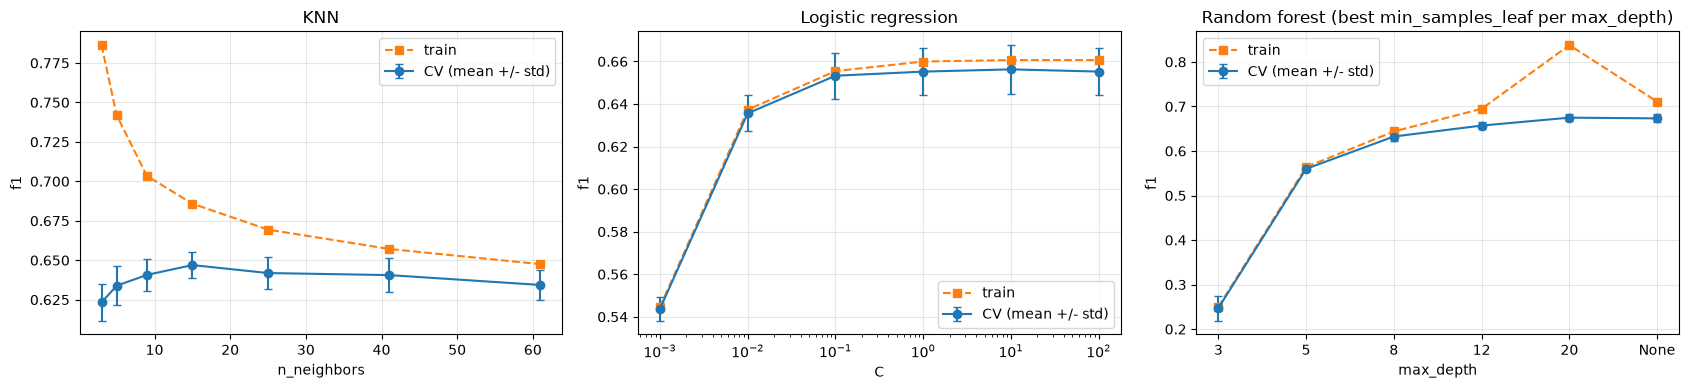

In [ ]:
def plot_param(ax, g, param, title, log_x=False):
    res = pd.DataFrame(g.cv_results_)
    key = f"param_{param}"
    res["x"] = res[key].apply(lambda v: "None" if v is None or (isinstance(v, float) and np.isnan(v)) else v)
    best = res.loc[res.groupby("x", sort=False)["mean_test_score"].idxmax()]
    xs = np.arange(len(best)) if best["x"].map(lambda v: isinstance(v, str)).any() else best["x"].astype(float).values
    ax.errorbar(xs, best["mean_test_score"], yerr=best["std_test_score"], marker="o", capsize=3, label="CV (mean +/- std)")
    ax.plot(xs, best["mean_train_score"], marker="s", linestyle="--", label="train")
    if isinstance(xs, np.ndarray) and xs.dtype != float or best["x"].map(lambda v: isinstance(v, str)).any():
        ax.set_xticks(xs); ax.set_xticklabels(best["x"].astype(str))
    if log_x: ax.set_xscale("log")
    ax.set_xlabel(param.replace("clf__", "")); ax.set_ylabel(MAIN_METRIC)
    ax.set_title(title); ax.grid(alpha=.3); ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
plot_param(axes[0], grids["KNN"], "clf__n_neighbors", "KNN")
plot_param(axes[1], grids["Logistic regression"], "clf__C", "Logistic regression", log_x=True)
plot_param(axes[2], grids["Random forest"], "clf__max_depth", "Random forest (best min_samples_leaf per max_depth)")
plt.tight_layout(); plt.show()

In [ ]:
rows = []
for name, g in grids.items():
    i = g.best_index_
    rows.append({"model": name, "best params": g.best_params_,
                 f"CV {MAIN_METRIC} mean": g.cv_results_["mean_test_score"][i],
                 f"CV {MAIN_METRIC} std": g.cv_results_["std_test_score"][i]})
rows.append({"model": "Baseline (most frequent)", "best params": "-",
             f"CV {MAIN_METRIC} mean": base_main.mean(), f"CV {MAIN_METRIC} std": base_main.std()})
cv_table = pd.DataFrame(rows).set_index("model")
cv_table.round(3)

,best params,CV f1 mean,CV f1 std
model,,,
KNN,{'clf__n_neighbors': 15},0.647,0.008
Logistic regression,{'clf__C': 10},0.656,0.011
Random forest,"{'clf__max_depth': 20, 'clf__min_samples_leaf'...",0.675,0.009
Baseline (most frequent),-,0.000,0.000


## Step 7: Evaluate once on the test set
The tuned models were refitted on the full training set (`refit=True`). The test set is used here for the first and only time.

In [ ]:
baseline.fit(X_train, y_train_bin)
final_models = {"Baseline (most frequent)": baseline,
                **{name: g.best_estimator_ for name, g in grids.items()}}

pred_test = {name: m.predict(X_test) for name, m in final_models.items()}
pred_train = {name: m.predict(X_train) for name, m in final_models.items()}

rows = []
for name in final_models:
    rows.append({"model": name,
                 "precision (test)": precision_score(y_test_bin, pred_test[name], zero_division=0),
                 "recall (test)": recall_score(y_test_bin, pred_test[name], zero_division=0),
                 "F1 train": f1_score(y_train_bin, pred_train[name], zero_division=0),
                 "F1 CV": cv_table.loc[name, f"CV {MAIN_METRIC} mean"],
                 "F1 test": f1_score(y_test_bin, pred_test[name], zero_division=0)})
results = pd.DataFrame(rows).set_index("model")
results["gap train-test"] = results["F1 train"] - results["F1 test"]
results.round(3)

,precision (test),recall (test),F1 train,F1 CV,F1 test,gap train-test
model,,,,,,
Baseline (most frequent),0.000,0.000,0.000,0.000,0.000,0.000
KNN,0.706,0.614,0.684,0.647,0.657,0.027
Logistic regression,0.740,0.617,0.660,0.656,0.673,-0.013
Random forest,0.790,0.621,0.822,0.675,0.695,0.127


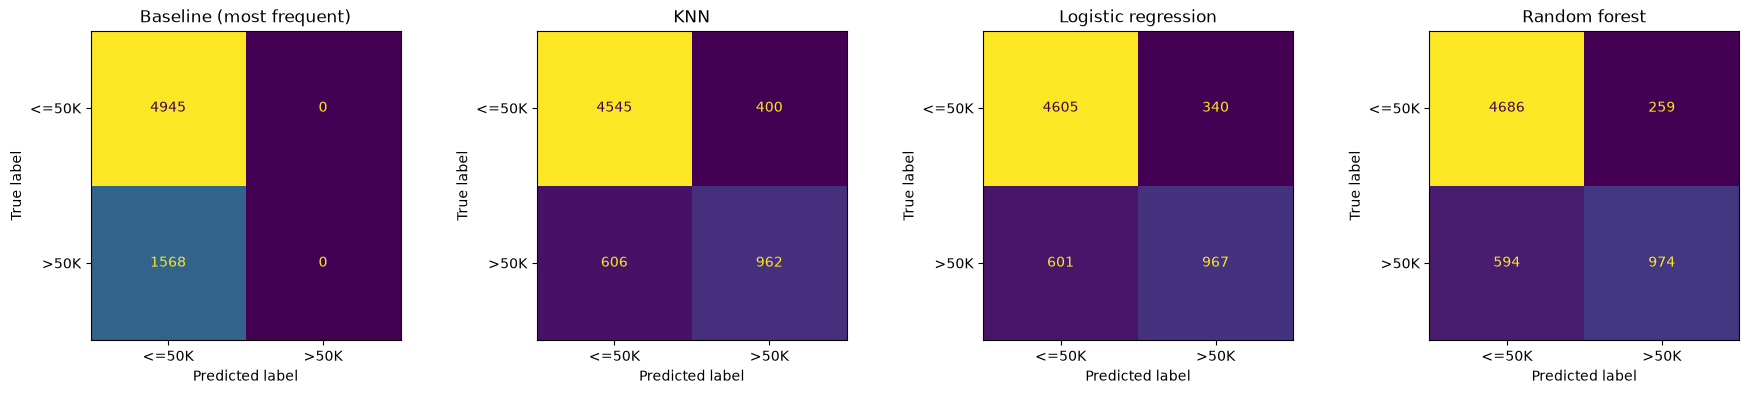

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, final_models):
    ConfusionMatrixDisplay(confusion_matrix(y_test_bin, pred_test[name]),
                           display_labels=["<=50K", ">50K"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

In [ ]:
print(cv_table.drop(index="Baseline (most frequent)").round(3).iloc[:, 1:].to_string())

                     CV f1 mean  CV f1 std
model                                     
KNN                       0.647      0.008
Logistic regression       0.656      0.011
Random forest             0.675      0.009


## Recommendation helper and prediction for a new case

In [30]:
RECOMMENDED = "Logistic regression"

new_case = pd.DataFrame([{
    "age": 34, "workclass": "Private", "fnlwgt": 190000, "education": "Bachelors", "education_num": 13,
    "marital_status": "Married-civ-spouse", "occupation": "Prof-specialty", "relationship": "Husband",
    "race": "White", "sex": "Male", "capital_gain": 0, "capital_loss": 0, "hours_per_week": 45,
    "native_country": "United-States"}])[X_train.columns]

model = final_models[RECOMMENDED]
proba = model.predict_proba(new_case)[0, 1]
print(f"Model: {RECOMMENDED}")
print(f"Prediction: {'>50K' if proba >= 0.5 else '<=50K'}  (probability of >50K: {proba:.2f})")

Model: Logistic regression
Prediction: >50K  (probability of >50K: 0.56)
